In [15]:
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import json

In [16]:
aggregated = []
with open('../benchmarks/aggregated_results.json') as f:
  aggregated = json.load(f)


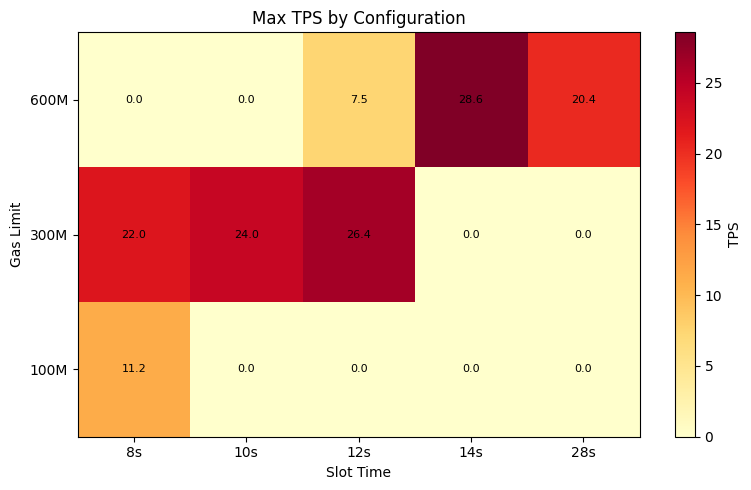

In [17]:
# --- Heatmap: best TPS for each (slot_time, gas_limit) ---
# For each (slot, gas), take the max mean TPS across all voter counts
config_tps = defaultdict(float)
for entry in aggregated:
    key = (entry['slot_time'], entry['gas_limit_M'])
    
    if entry['tps'] and entry['tps']['mean'] > config_tps[key]:
        config_tps[key] = entry['tps']['mean']

if config_tps:
    slots = sorted(set(k[0] for k in config_tps))
    gases = sorted(set(k[1] for k in config_tps))
    matrix = np.zeros((len(gases), len(slots)))
    for i, gas in enumerate(gases):
        for j, slot in enumerate(slots):
            matrix[i, j] = config_tps.get((slot, gas), 0)

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', origin='lower')
    ax.set_xticks(range(len(slots)))
    ax.set_xticklabels([f'{s}s' for s in slots])
    ax.set_yticks(range(len(gases)))
    ax.set_yticklabels([f'{g}M' for g in gases])
    ax.set_xlabel('Slot Time')
    ax.set_ylabel('Gas Limit')
    ax.set_title('Max TPS by Configuration')
    for i in range(len(gases)):
        for j in range(len(slots)):
            ax.text(j, i, f'{matrix[i, j]:.1f}', ha='center', va='center', fontsize=8)
    fig.colorbar(im, label='TPS')
    
    plt.tight_layout()
    plt.show()

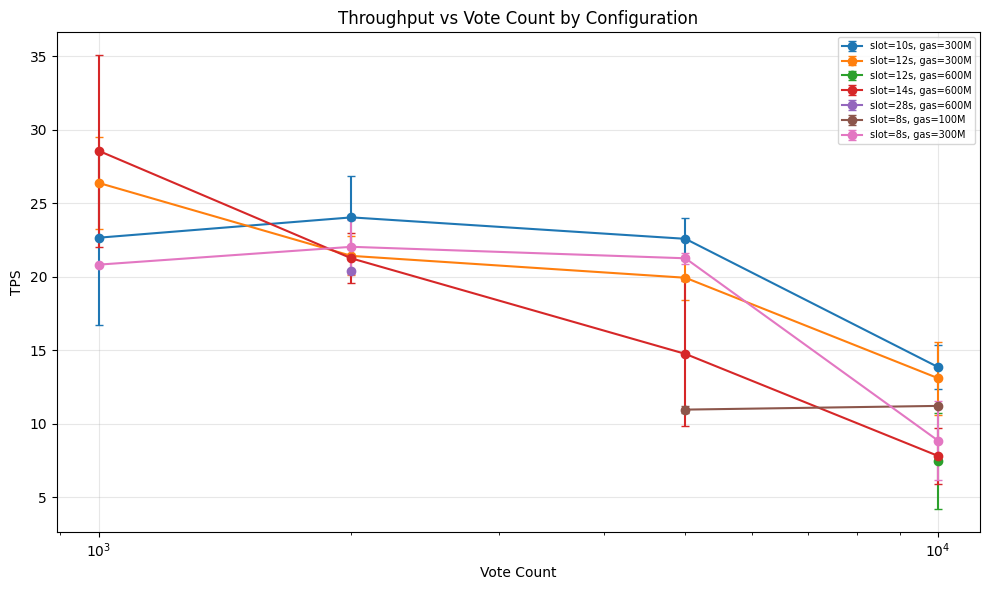

In [18]:
# --- Line plot: TPS vs voters for each config ---
configs = defaultdict(list)
for entry in aggregated:
    label = f"slot={entry['slot_time']}s, gas={entry['gas_limit_M']}M"
    configs[label].append(entry)

if configs:
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, entries in sorted(configs.items()):
        entries_sorted = sorted(entries, key=lambda e: e['voters'])
        x = [e['voters'] for e in entries_sorted]
        y = [e['tps']['mean'] for e in entries_sorted if e['tps']]
        yerr = [e['tps']['std'] for e in entries_sorted if e['tps']]
        if y:
            ax.errorbar(x[:len(y)], y, yerr=yerr, marker='o', label=label, capsize=3)

    ax.set_xlabel('Vote Count')
    ax.set_ylabel('TPS')
    ax.set_title('Throughput vs Vote Count by Configuration')
    ax.legend(fontsize=7, loc='best')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

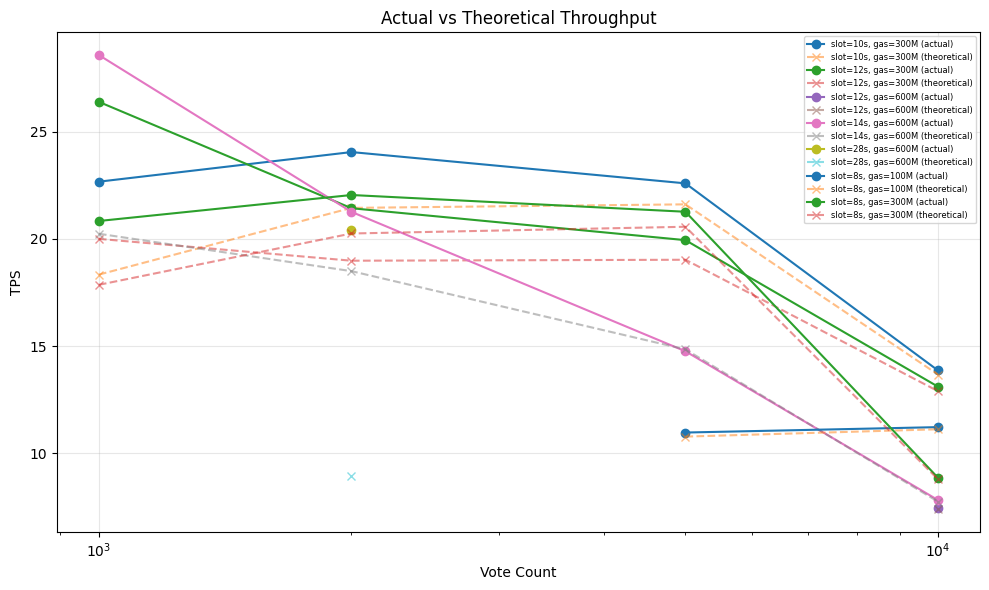

In [19]:
# --- Line plot: TPS vs voters with theoretical throughput ---
if configs:
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, entries in sorted(configs.items()):
        entries_sorted = sorted(entries, key=lambda e: e['voters'])
        x = [e['voters'] for e in entries_sorted]
        y_actual = [e['tps']['mean'] for e in entries_sorted if e['tps']]
        y_theoretical = [e['theoretical_tps'] for e in entries_sorted]
        if y_actual:
            ax.plot(x[:len(y_actual)], y_actual, marker='o', label=f'{label} (actual)')
            ax.plot(x[:len(y_theoretical)], y_theoretical[:len(y_actual)],
                    marker='x', linestyle='--', alpha=0.5, label=f'{label} (theoretical)')

    ax.set_xlabel('Vote Count')
    ax.set_ylabel('TPS')
    ax.set_title('Actual vs Theoretical Throughput')
    ax.legend(fontsize=6, loc='best')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.show()

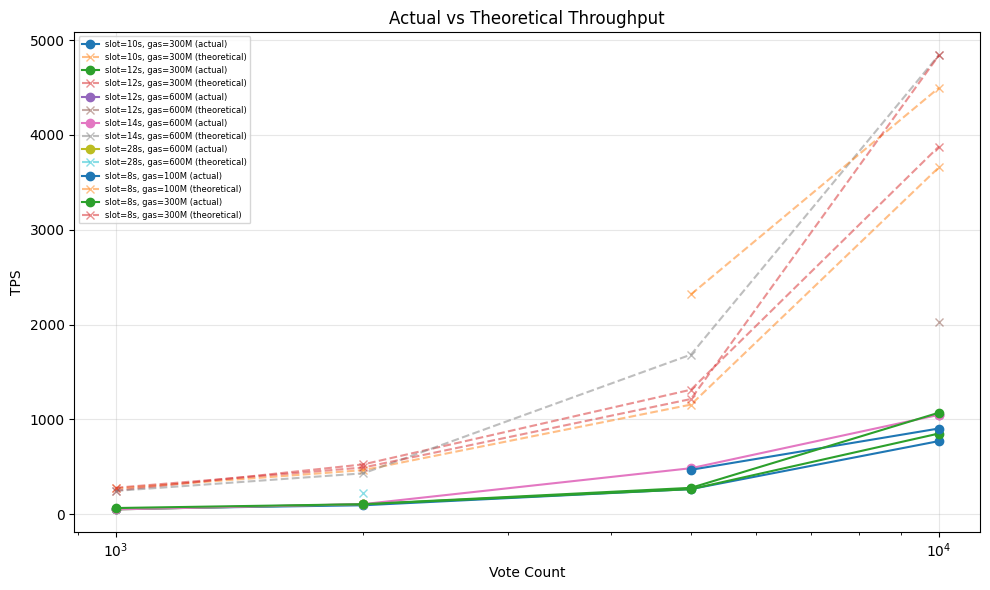

In [20]:
# --- Line plot: TPS vs voters with theoretical throughput ---
if configs:
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, entries in sorted(configs.items()):
        entries_sorted = sorted(entries, key=lambda e: e['voters'])
        x = [e['voters'] for e in entries_sorted]
        y_actual = [e['vote_time_s']['mean'] for e in entries_sorted if e['vote_time_s']]
        y_theoretical = [e['theoretical_vote_time'] for e in entries_sorted]
        if y_actual:
            ax.plot(x[:len(y_actual)], y_actual, marker='o', label=f'{label} (actual)')
            ax.plot(x[:len(y_theoretical)], y_theoretical[:len(y_actual)],
                    marker='x', linestyle='--', alpha=0.5, label=f'{label} (theoretical)')

    ax.set_xlabel('Vote Count')
    ax.set_ylabel('TPS')
    ax.set_title('Actual vs Theoretical Throughput')
    ax.legend(fontsize=6, loc='best')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.show()

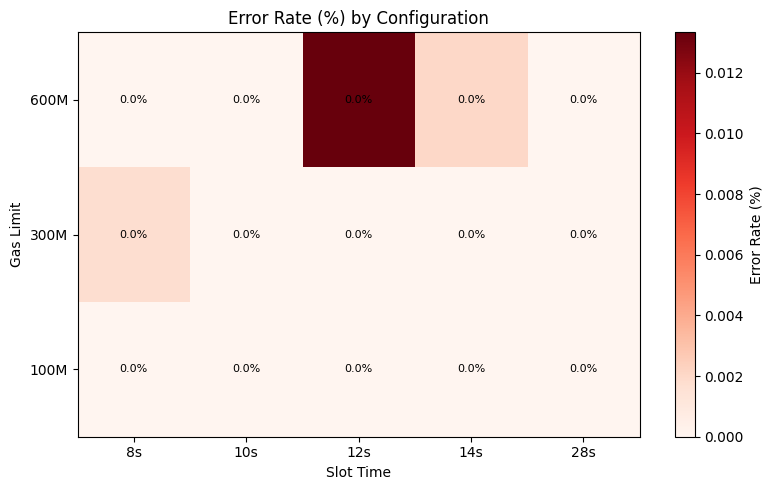

In [21]:
# --- Heatmap: error rate ---
config_err = defaultdict(list)
for entry in aggregated:
    key = (entry['slot_time'], entry['gas_limit_M'])
    config_err[key].append(entry['error_rate'])

if config_err:
    slots = sorted(set(k[0] for k in config_err))
    gases = sorted(set(k[1] for k in config_err))
    matrix = np.zeros((len(gases), len(slots)))
    for i, gas in enumerate(gases):
        for j, slot in enumerate(slots):
            vals = config_err.get((slot, gas), [0])
            matrix[i, j] = np.mean(vals) * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(matrix, aspect='auto', cmap='Reds', origin='lower')
    ax.set_xticks(range(len(slots)))
    ax.set_xticklabels([f'{s}s' for s in slots])
    ax.set_yticks(range(len(gases)))
    ax.set_yticklabels([f'{g}M' for g in gases])
    ax.set_xlabel('Slot Time')
    ax.set_ylabel('Gas Limit')
    ax.set_title('Error Rate (%) by Configuration')
    for i in range(len(gases)):
        for j in range(len(slots)):
            ax.text(j, i, f'{matrix[i, j]:.1f}%', ha='center', va='center', fontsize=8)
    fig.colorbar(im, label='Error Rate (%)')
    
    plt.tight_layout()
    plt.show()